In [10]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/diabetes_prediction_dataset.csv')

In [13]:
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [14]:
data.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [15]:
data.shape

(100000, 9)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [17]:
data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [18]:
data.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [19]:
data.duplicated().sum()

np.int64(3854)

In [20]:
data = data.drop_duplicates()

In [21]:
data.duplicated().sum()

np.int64(0)

In [22]:
data.shape

(96146, 9)

In [23]:
data['diabetes'].value_counts()

,count
diabetes,
0,87664
1,8482


In [24]:
data['diabetes'].value_counts(normalize=True) * 100

,proportion
diabetes,
0,91.178
1,8.822


In [25]:
print(data['gender'].unique())

['Female' 'Male' 'Other']


In [26]:
print(data['smoking_history'].unique())

['never' 'No Info' 'current' 'former' 'ever' 'not current']


In [27]:
data = pd.get_dummies(
    data,
    columns=['gender', 'smoking_history'],
    dtype=int
)

In [28]:
data.columns

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'gender_Female', 'gender_Male',
       'gender_Other', 'smoking_history_No Info', 'smoking_history_current',
       'smoking_history_ever', 'smoking_history_former',
       'smoking_history_never', 'smoking_history_not current'],
      dtype='object')

In [29]:
data.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,1,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,1,0,0,1,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,0,1,0,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,0,1,0,0,1,0,0,0,0


In [30]:
X = data.drop('diabetes', axis=1)
y = data['diabetes']

In [31]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96146, 15)
y shape: (96146,)


### Spliting the data

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Checking Split

In [33]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (76916, 15)
Testing data: (19230, 15)


### Scaling

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
X = data.drop('diabetes', axis=1)
y = data['diabetes']

In [36]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96146, 15)
y shape: (96146,)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (76916, 15)
Testing data: (19230, 15)


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train using Logistic Regression

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

### Train the Model

In [41]:
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Making Prediction

In [42]:
y_pred = model.predict(X_test_scaled)

### Calculating Accuracy

In [43]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8845553822152886
Accuracy (%): 88.45553822152887


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.89      0.93     17534
           1       0.43      0.88      0.57      1696

    accuracy                           0.88     19230
   macro avg       0.71      0.88      0.75     19230
weighted avg       0.94      0.88      0.90     19230



In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[15518  2016]
 [  204  1492]]


In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

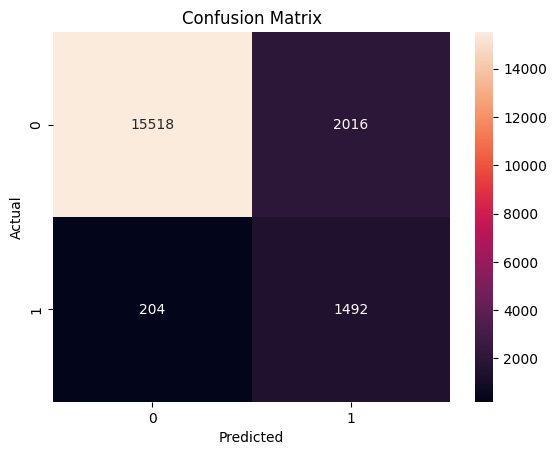

In [48]:
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

### Train using Decision Tree

In [57]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [58]:
y_pred_dt = dt_model.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9506500260010401

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     17534
           1       0.71      0.74      0.73      1696

    accuracy                           0.95     19230
   macro avg       0.84      0.86      0.85     19230
weighted avg       0.95      0.95      0.95     19230



### Building Random Forest

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [61]:
y_pred_rf = rf_model.predict(X_test)

In [62]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.968798751950078

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.94      0.69      0.80      1696

    accuracy                           0.97     19230
   macro avg       0.95      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



### Model comparison table

In [63]:
results = {
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
}

results_df = pd.DataFrame(results)

results_df['Accuracy'] = results_df['Accuracy'] * 100

results_df

,Model,Accuracy
0,Logistic Regression,88.455538
1,Decision Tree,95.065003
2,Random Forest,96.879875


### Feature Importance


In [64]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
4,HbA1c_level,0.347647
5,blood_glucose_level,0.262952
0,age,0.181112
3,bmi,0.132647
1,hypertension,0.027832
2,heart_disease,0.015253
9,smoking_history_No Info,0.010371
12,smoking_history_former,0.005788
13,smoking_history_never,0.003366
7,gender_Male,0.003358


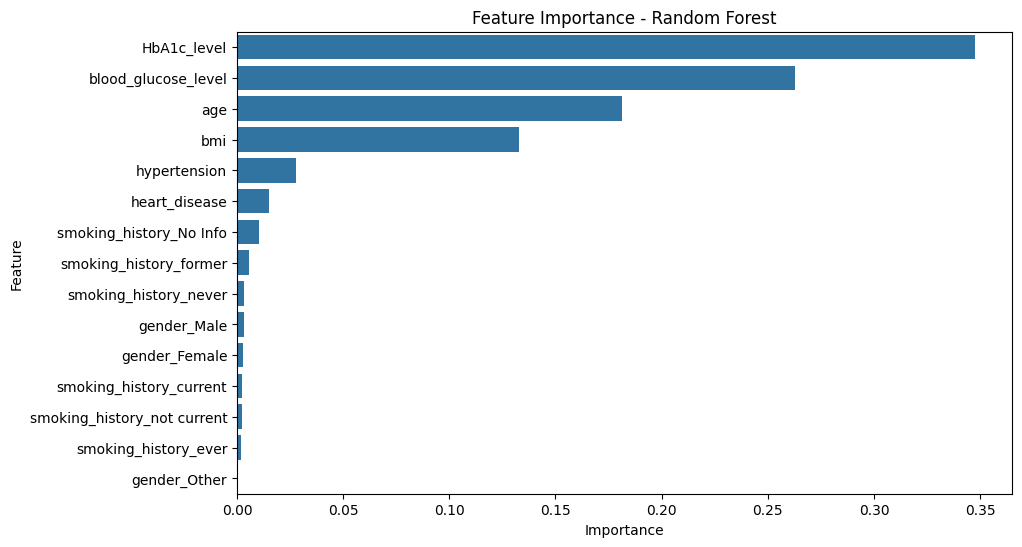

In [65]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

### Confusion Matrix for Random Forest

In [66]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[17457    77]
 [  523  1173]]


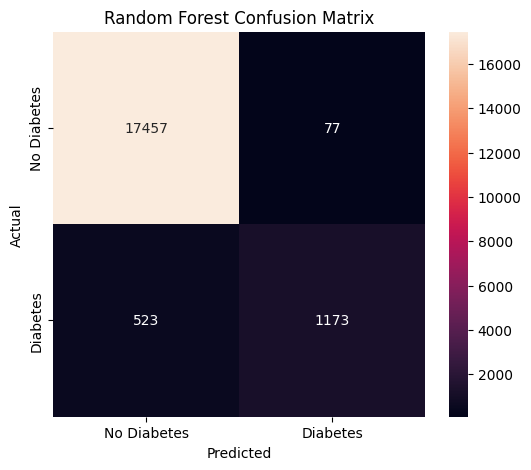

In [67]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

plt.show()